In [1]:
import sys
import numpy as np
import torch 
import pandas as pd
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import matplotlib.pyplot as plt

from scipy.stats import beta
from sklearn.utils import resample

2.3.0+cu121
12.1
2.3.0+cu121
12.1


In [2]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


In [3]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file='/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/LeafletAnalysis/mouse_whole_cortex_dev_leaflet.h5'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=100000, remove_singletons=True, has_genes="yes")

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  20857
Number of junctions after removing singletons:  20857
The number of unique cell types in the data is:  9
The number of unique cells in the data is:  18
The number of unique junctions in the data is:  20858
The maximum junction count was initially:  42464
0
The maximum junction count is now:  42464
The number of junctions in the data is:  20858
The number of cells in the data is:  18
The number of cell types in the data is:  9
The number of cells going into training data is:
18
18


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


The number of junctions is:  20858
The number of intron clusters observed is:  7192
The number of genes is:  5412
The number of cells is:  18


In [4]:
# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [5]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [6]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [7]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [8]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [9]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.03426609560946503


In [10]:
reload(factor_model)

2.3.0+cu121
12.1


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 1022
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model


/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(hyperparam, dtype=torch.float32)
/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(hyperparam, dtype=torch.float32)


Epoch 0, Elbo loss: 25068888.244107947
Epoch 40, Elbo loss: 2021127.0918368453
Epoch 80, Elbo loss: 1440309.1340910667


INFO:root:Elbo loss: 1386454.834435728


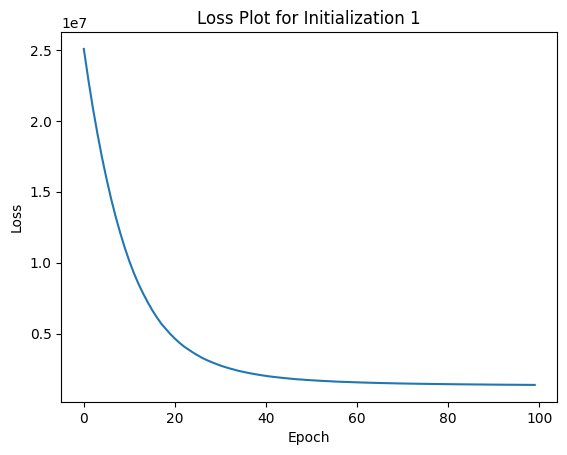

Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 3067
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 25762118.67264742
Epoch 40, Elbo loss: 1993064.9832376225
Epoch 80, Elbo loss: 1427560.112883023


INFO:root:Elbo loss: 1374760.0613768587


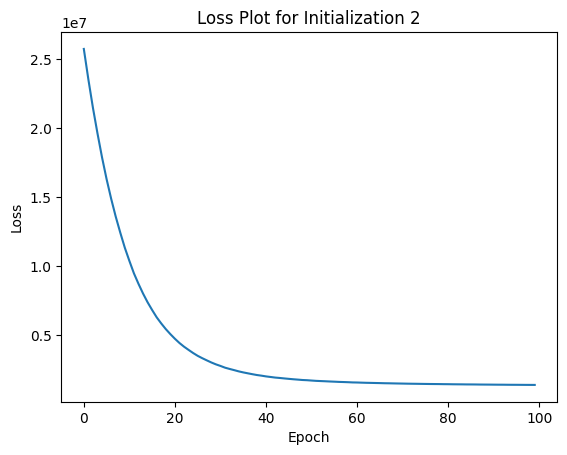

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [11]:
best_K = 10
K = best_K

# make input conc infinity first 
input_conc = torch.tensor(np.inf, **float_type)

# import torch.distributions as dist
# input_conc = dist.Gamma(concentration=2.0, rate=2.0)

#input_conc = 1
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=2, use_global_prior=True, input_conc=input_conc, K=K, lr=0.1, loss_plot=True, num_epochs=100, save_to_file = False)

In [12]:
import pyro
# fetch optimized guide parameters, each (loc, scale) pair parameterizes a single normal distribution in the guide corresponding to a different unobserved pyro.sample statement in the model
for name, value in pyro.get_param_store().items():
    print(name, pyro.param(name))

AutoDiagonalNormal.loc Parameter containing:
tensor([ 0.1716,  0.2892,  0.2581,  ..., -1.0527,  3.7617, -3.0898],
       requires_grad=True)
AutoDiagonalNormal.scale tensor([0.1904, 0.1963, 0.2678,  ..., 0.0380, 0.0506, 0.0558],
       grad_fn=<SoftplusBackward0>)


In [13]:
# extract latent variables for just first seed used 
latent_vars = all_results[1]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k

dir_conc = latent_vars["dir_conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))

[0.80844057 1.5881228  1.3714926  ... 0.53691435 0.28992438 0.37983367]
[2.4095867 2.4436395 2.882418  ... 1.7411119 3.793425  4.37044  ]
The inferred concentration parameter is: 4.0040593
The inferred pi parameter is: [0.07574926 0.1773531  0.11062406 0.1774603  0.09031592 0.07878881
 0.08854301 0.10676093 0.03442557 0.05997905]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

plot_bb = False 

if plot_bb:

    # Generate values for the x-axis
    x = np.linspace(0, 1, 1000)

    # Calculate the probability density function (PDF) of the beta distribution
    pdf = beta.pdf(x, a, b)

    # Plot the beta distribution
    plt.plot(x, pdf)
    plt.title('Beta Distribution')
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [17]:
samples_order = ["E14.5", "E16.5", "P0", "P4", "P7", "P15", "P30", "P110", "21M"]

['E14.5', 'E16.5', 'P0', 'P4', 'P7', 'P15', 'P30', 'P110', '21M']


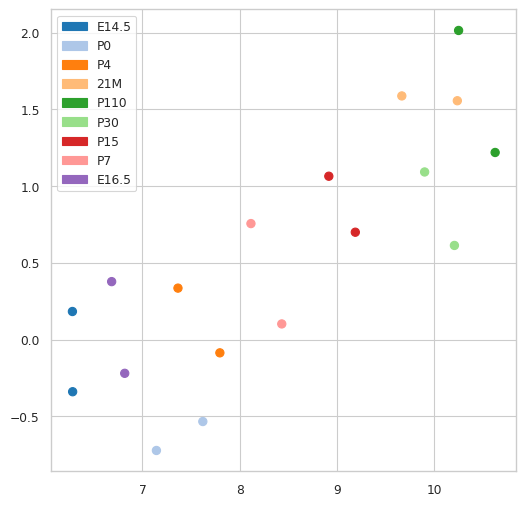

In [18]:
# plot UMAP 
# add whitegrid 
import matplotlib.patches as mpatches

sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))

cell_types = cell_ids_conversion.cell_type

cell_types_unique = cell_types.unique()
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))
cell_colors = cell_types.map(cell_type_dict)

# Plot the UMAP embedding
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=35, c=cell_colors
)

# Create legend handles and labels
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]

# Add legend to the plot
plt.legend(handles=legend_handles)

print(samples_order)

In [19]:
# giw dies UMAP look for gene expression data? 

In [20]:
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
pi

array([0.07574926, 0.1773531 , 0.11062406, 0.1774603 , 0.09031592,
       0.07878881, 0.08854301, 0.10676093, 0.03442557, 0.05997905],
      dtype=float32)

         pi    Factor
3  0.177460  Facotor3
1  0.177353  Facotor1
2  0.110624  Facotor2
7  0.106761  Facotor7
4  0.090316  Facotor4


/scratch/ipykernel_26985/540431722.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")


Text(0.5, 1.0, 'Overall contribution of each factor to cell population')

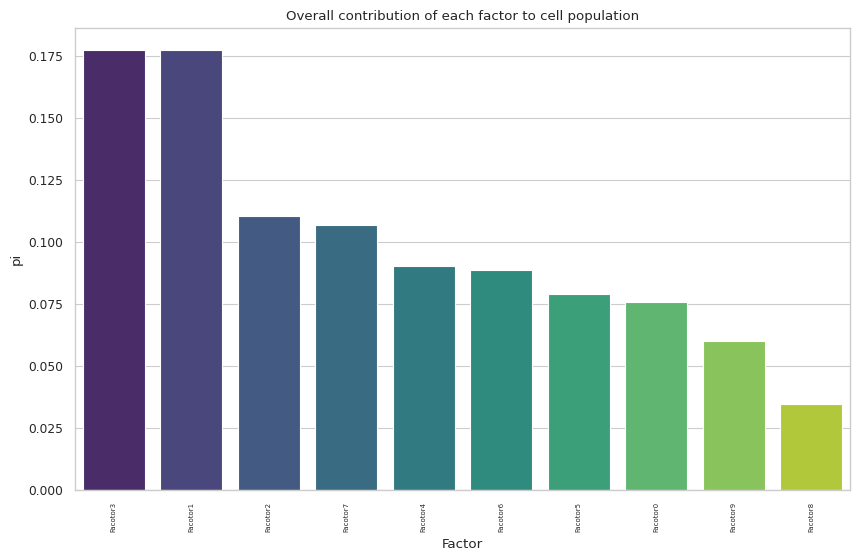

In [21]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=5)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")

In [22]:
# which splice junctions are very activated in factor 8 
psi = latent_vars["psi"]

# convert into a data frame
psi_df = pd.DataFrame(psi)

In [24]:
# make a new column wiht values from 1 to 9 to indiciate numerically the cell types in order E14.5 should be 1 and 21M should be 9 
cell_ids_conversion["cell_type_num"] = cell_ids_conversion.cell_type.replace(dict(zip(samples_order, range(1, 10))))

/scratch/ipykernel_26985/31783681.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_ids_conversion["cell_type_num"] = cell_ids_conversion.cell_type.replace(dict(zip(samples_order, range(1, 10))))


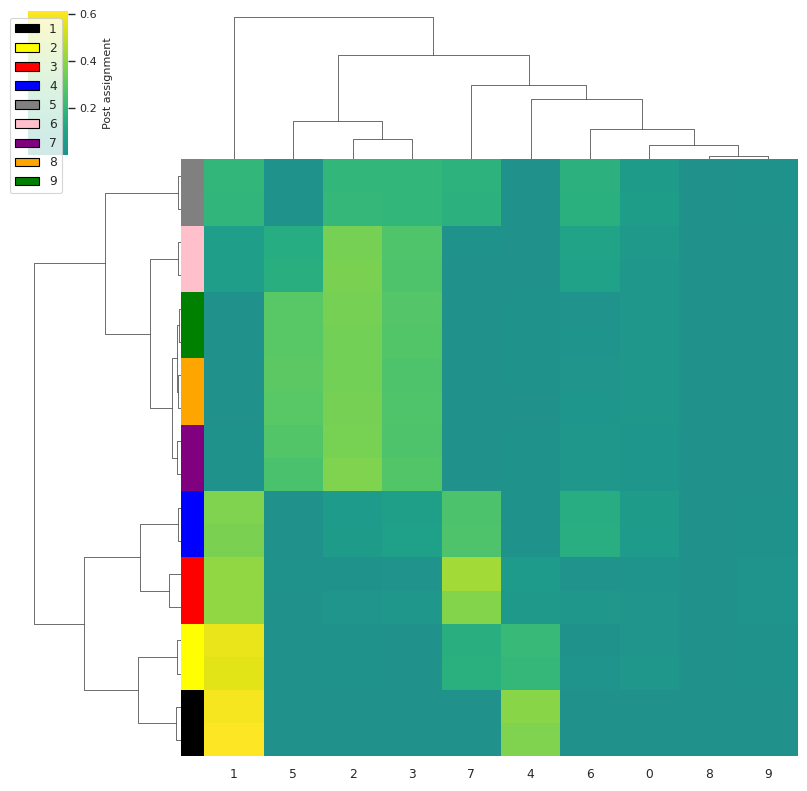

In [26]:
import seaborn as sns
from matplotlib.patches import Patch

# Define your custom color palette
custom_palette = ["black", "red", "blue", "green", "orange", "purple", "pink", "grey", "yellow"]

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type_num'].unique()
num_unique_types = len(unique_cell_types)
colors = custom_palette[:num_unique_types]  # Ensure you have enough colors in your custom palette

# Create a dictionary mapping cell types to colors
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}

# Get cell type labels for each cell
cell_types = cell_ids_conversion.cell_type_num.values

# Create a list of colors for each cell based on its cell type
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

# Use the custom color palette in your clustermap
cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
)

# Set label for color bar
cluster.cax.set_ylabel('Post assignment', size=8)

# Increase font size for color bar tick labels
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

legend_elements = [Patch(facecolor=cell_type_colors[key], edgecolor='black', label=str(key)) for key in sorted(cell_type_colors.keys())]
plt.legend(handles=legend_elements, loc='upper right')


In [70]:
from scipy.stats import beta

def assess_significance_individual(observed_psi_kj, a_j, b_j, num_iterations=1000, alpha=0.05):
    """
    Assess the significance of individual observed PSI values for a given junction compared to its average behavior,
    using a Beta distribution defined by parameters a_j and b_j.

    Parameters:
    - observed_psi_kj (array-like): Observed PSI values for the junction in a specific cell state.
    - a_j (float): Parameter 'a' representing the average behavior across all cell states.
    - b_j (float): Parameter 'b' representing the average behavior across all cell states.
    - num_iterations (int, optional): Number of iterations for bootstrap resampling. Defaults to 100.
    - alpha (float, optional): Significance level for confidence intervals. Defaults to 0.05.

    Returns:
    - results_sig (list of bool): List indicating significance for each observed PSI.
    - confidence_interval (tuple): Confidence interval for the average PSI.
    """
    
    # Generate bootstrap samples from the Beta distribution defined by a_j and b_j
    bootstrap_samples = beta.rvs(a_j, b_j, size=num_iterations)

    # Get likelihood of observing observed_psi_kj values under a_j and b_j
    pdf_values = beta.pdf(observed_psi_kj, a_j, b_j)

    # Calculate the confidence interval for the bootstrap samples
    lower_bound = np.percentile(bootstrap_samples, (alpha / 2) * 100)
    upper_bound = np.percentile(bootstrap_samples, (1 - alpha / 2) * 100)
    confidence_interval = (lower_bound, upper_bound)

    # Assess if each observed PSI value is outside the confidence interval
    results_sig = [(psi < lower_bound or psi > upper_bound) for psi in observed_psi_kj]

    # Average baseline junction 
    avg_j = a_j/(a_j+b_j)

    return results_sig, confidence_interval, avg_j, pdf_values

In [71]:
J = junction_ids_conversion.shape[0]

# sample 100 random numbers in range(J)
J = 5000
print(J)

# Initialize lists to store results
junction_ids = []
observed_psis_list = []
mean_junc = []
is_significant_list = []
conf_int_list = []
pdf_values = []

# Iterate over each junction
for j in tqdm(range(J)):
    observed_psis = psi[:, j]
    a_j = a[j]
    b_j = b[j]

    # Assess significance for the current junction
    junc_sig, confidence_intervals, avg_junc, pdf_vals = assess_significance_individual(observed_psis, a_j, b_j, num_iterations=300, alpha=0.05)

    # Append results to lists
    junction_ids.append(j)
    observed_psis_list.append(observed_psis)
    mean_junc.append(avg_junc)
    is_significant_list.append(junc_sig)
    conf_int_list.append(confidence_intervals)
    pdf_values.append(pdf_vals)

# Create a DataFrame from the lists
results_df = pd.DataFrame({
    'Junction_ID': junction_ids,
    'Observed_PSI': observed_psis_list,
    'mean_junc': mean_junc,
    'Is_Significant': is_significant_list,
    'Confidence_Intervals': conf_int_list,
    'pdf_values': pdf_values
})

5000


100%|██████████| 5000/5000 [00:04<00:00, 1109.31it/s]


In [72]:
# Assuming 'results_df' is already defined and contains the 'Is_Significant' data as described

# Convert the 'Is_Significant' column, which is a list of lists, into a DataFrame
is_significant_df = pd.DataFrame(results_df['Is_Significant'].tolist())

# Calculate the proportion of True values for each junction
# `mean(axis=0)` will calculate the mean down the columns, i.e., across all junctions
proportion_significant = is_significant_df.sum(axis=1)

# Add the proportion_significant column to the original DataFrame
results_df['Proportion_Significant'] = proportion_significant

# Sort the DataFrame based on the proportion of significant values, in descending order
sorted_df = results_df.sort_values(by='Proportion_Significant', ascending=False)

In [73]:
psi_df = pd.DataFrame(psi.T)

In [74]:
sorted_df.head()

,Junction_ID,Observed_PSI,mean_junc,Is_Significant,Confidence_Intervals,pdf_values,Proportion_Significant
2684,2684,"[0.27019638, 0.30674398, 0.12089708, 0.4664064...",0.094451,"[False, True, False, True, False, False, True,...","(0.0024051251606320664, 0.2972449732130064)","[0.648505728995789, 0.42120016175450764, 3.125...",5
3899,3899,"[0.016257849, 0.008726154, 0.11189007, 0.01368...",0.572097,"[True, True, False, True, False, False, False,...","(0.0312656928872293, 0.9956479598251654)","[0.7359834278623697, 0.7306099704472281, 0.767...",4
2104,2104,"[0.118950635, 0.09108753, 0.6774737, 0.6823208...",0.651920,"[True, True, False, False, False, False, False...","(0.1298258876259721, 0.9841435367696094)","[0.2738856143115848, 0.21311747018843336, 1.36...",4
2326,2326,"[0.72584903, 0.2844966, 0.7037399, 0.8379343, ...",0.575716,"[False, False, False, False, True, True, False...","(0.17001438553904208, 0.9522502303061229)","[1.356742517347732, 0.8878704336224573, 1.3556...",4
4608,4608,"[0.36493224, 0.6703759, 0.54889715, 0.704068, ...",0.198224,"[False, True, True, True, False, False, False,...","(0.004934425740932474, 0.5177397529377258)","[1.006214834950597, 0.1464399182439204, 0.3670...",4


In [75]:
def plot_psi_with_confidence_interval(mean_junc, conf_int, psi_values, junction_id):
    """
    Plot the PSI values for a junction with the mean and confidence interval.

    Parameters:
    - mean_junc (float or Series): The mean PSI value for the junction.
    - conf_int (tuple or Series): The confidence interval (lower, upper) for the mean PSI.
    - psi_values (list or array): List or array of individual PSI values for the junction.
    - junction_id (int): Identifier for the junction.
    """
    # Check if mean_junc or conf_int are pandas Series and extract values if necessary
    if isinstance(mean_junc, pd.Series):
        mean_junc = mean_junc.iloc[0]  # Assuming mean_junc is a single value in a Series
    if isinstance(conf_int, pd.Series):
        conf_int = conf_int.iloc[0]  # Assuming conf_int is a tuple inside a Series
    
    # Extract lower and upper bounds from the confidence interval
    lower, upper = conf_int
    plt.figure(figsize=(6, 6))
    
    # get gene name that junction is in 
    gene_name = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == j].gene_id.values
    junction_id = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == j].junction_id.values
    print(j, gene_name, junction_id)
    
    plt.title(f"PSI Visualization for Junction {j} in \nGene {gene_name} ({junction_id})")
    plt.xlabel("Cell States")
    plt.ylabel("PSI Values")
    
    # Extract lower and upper bounds from the confidence interval
    lower, upper = conf_int
    
    # Plot the mean junction PSI as a red dot
    plt.scatter([-0.5], [mean_junc], color='red', zorder=5, label='Mean PSI')
    
    # add the confidence interval on mean junc using lower and upper should be vertical
    plt.vlines(x=-0.5, ymin=lower, ymax=upper, color='grey', linestyle='--', label='Confidence Interval')
    
    # Plot the individual PSI values
    plt.scatter(range(len(psi_values)), psi_values, color='blue', label='Individual PSI Values')
    
    # make ylim be 0 to 1 
    plt.ylim(0, 1)
    
    # Add legend and improve layout
    plt.legend()
    plt.grid(True)
    plt.xticks(range(len(psi_values)), labels=[f"{i+1}" for i in range(len(psi_values))])
    plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/scratch/ipykernel_26985/675139249.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cell_type_num", y="juncratio", data=quick_plot_data, palette="viridis")
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


The number of cells that have junction  2684  expressed is:  18
      Junction_ID                                       Observed_PSI  \
2684         2684  [0.27019638, 0.30674398, 0.12089708, 0.4664064...   

      mean_junc                                     Is_Significant  \
2684   0.094451  [False, True, False, True, False, False, True,...   

                             Confidence_Intervals  \
2684  (0.0024051251606320664, 0.2972449732130064)   

                                             pdf_values  \
2684  [0.648505728995789, 0.42120016175450764, 3.125...   

      Proportion_Significant  
2684                       5  
0.09445092


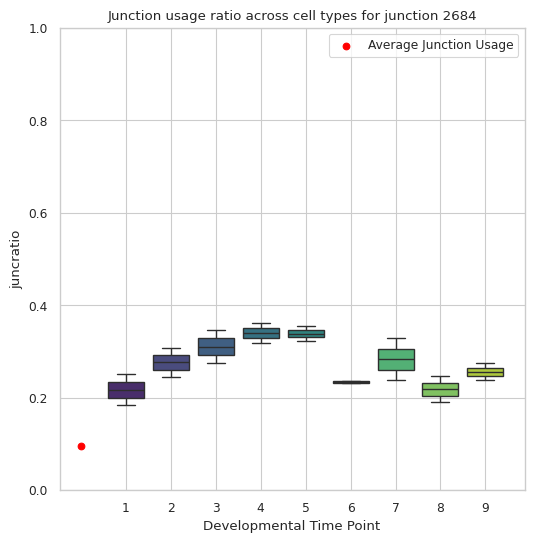

In [84]:
# let's write a function that plots junction usage ratio across cell types for a given junction 
j = np.random.choice(J)
j = 2684
# plot juncratio across cell types
quick_plot_data = simple_data[simple_data.junction_id_index == j]
quick_plot_data = quick_plot_data.merge(cell_ids_conversion, on=["cell_id_index"], how="left")

# print the number of cells that have this junction expressed 
print("The number of cells that have junction ", j, " expressed is: ", quick_plot_data.cell_id.nunique())

# print result from significance analysis
print(sorted_df[sorted_df["Junction_ID"] == j])

plt.figure(figsize=(6, 6))
sns.boxplot(x="cell_type_num", y="juncratio", data=quick_plot_data, palette="viridis")
plt.title("Junction usage ratio across cell types for junction "+str(j))
# make the ylim be 0 to 1
plt.ylim(0, 1)

# plot also baseline average junction usage which is a_j / (a_j+b_j) 
avg_junc = a[j] / (a[j] + b[j])
print(avg_junc)

# add a red dot indicating the avg_junc 
# Add a red dot indicating the avg_junc
plt.scatter(x=[-1], y=[avg_junc], color='red', label='Average Junction Usage')

# add xlab "Developmental Time Point"
plt.xlabel("Developmental Time Point")

# Show the plot
plt.legend()
plt.grid(True)
plt.show()

2684 ['ENSMUSG00000027963.15'] ['3_115801531_115804270']


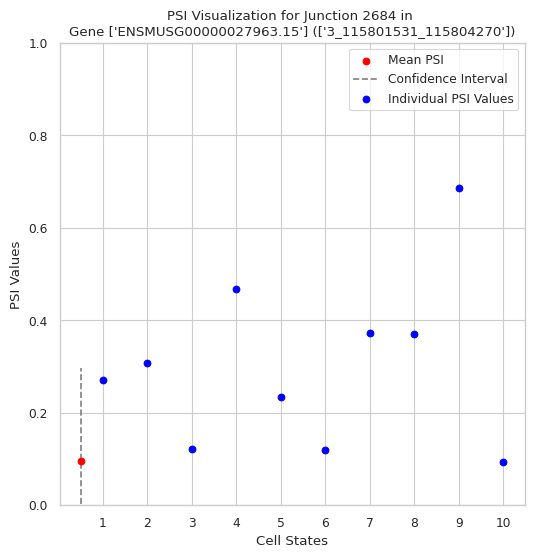

In [85]:
mean_junc = sorted_df[sorted_df["Junction_ID"] == j].mean_junc
conf_int = sorted_df[sorted_df["Junction_ID"] == j].Confidence_Intervals
psi_values = psi_df.iloc[j]
plot_psi_with_confidence_interval(mean_junc, conf_int, psi_values, j)

In [86]:
# which junctions are significant in cell state 1

# find rows where "Is_Significant" column at position 1 in the list is True 
cell_state1 = sorted_df[sorted_df["Is_Significant"].apply(lambda x: x[1])]


In [91]:
# get junctions ids 
juncs_state1 = cell_state1.Junction_ID.values

# extract PSI values for these junctions across all cell states 
psis_state1 = psi[:,juncs_state1]


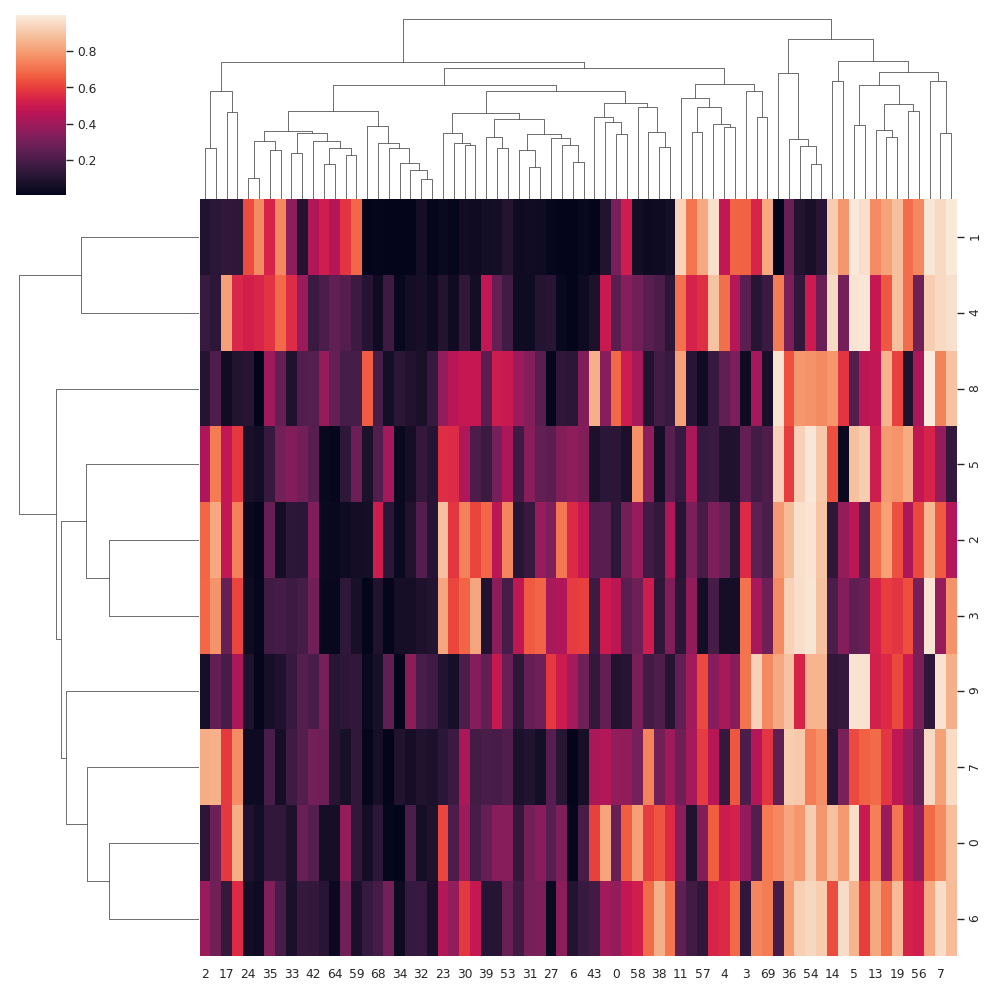

In [92]:
sns.clustermap(psis_state1)